# Notebook 08 — Horizon sweep

Visualize the multi-horizon backtest results for both targets across the four v1 models. Computed by `scripts/horizon_sweep.py`; data in `data/processed/backtest/horizon_sweep.csv`.

**Hypothesis to test (per `IMPLEMENTATION_PLAN_v2.md` §3 B.3):** BSTS's IC and hit-rate advantage *grows* at longer horizons, RMSE difference shrinks.

**Honest read of the data:** at the 1-week horizon, the AR baselines actually edge BSTS on IC for both targets. BSTS's value shows in **stability across horizons** — AR(4)+VIX collapses at long horizons (IC 0.44 → 0.10 for HY, RMSE blows up 1.7× to 1m×+); BSTS keeps moderate-positive IC throughout. The PM-relevant story is *forecast robustness*, not winning a single horizon.


In [1]:
import sys
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

p = Path.cwd().resolve()
while not (p / 'src' / 'gtrends_bayes').exists():
    if p == p.parent: raise RuntimeError('cannot find src/')
    p = p.parent
sys.path.insert(0, str(p / 'src'))
os.chdir(p)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/processed/backtest/horizon_sweep.csv')
print(f'rows: {len(df)} (expect 2 targets × 4 models × 5 horizons = 40)')
print(f'horizons: {sorted(df.horizon.unique())}')
print(f'models: {sorted(df.model.unique())}')
df.head(8)

rows: 40 (expect 2 targets × 4 models × 5 horizons = 40)
horizons: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(13)]
models: ['AR(4)', 'AR(4) + VIX', 'BSTS (Trends)', 'Naive RW']


,target,model,horizon,n_obs,rmse,hit_rate,ic_spearman,brier_score,auc,precision_widening,recall_widening,n_widening_events
0,HY,BSTS (Trends),1,214,2.1063,0.4860,0.5485,0.4184,0.3959,0.2615,0.5312,64
1,HY,BSTS (Trends),2,214,2.0240,0.4533,0.5195,0.3413,0.4661,0.2155,0.3968,63
2,HY,BSTS (Trends),4,214,2.4188,0.5514,0.5224,0.3062,0.4643,0.2874,0.4032,62
3,HY,BSTS (Trends),8,214,2.6443,0.5794,0.5076,0.2913,0.5130,0.3678,0.5079,63
4,HY,BSTS (Trends),13,214,3.1918,0.6168,0.4438,0.2809,0.6466,0.3258,0.4833,60
5,HY,AR(4),1,214,1.6914,0.4533,0.6036,0.4298,0.3840,0.2595,0.6406,64
6,HY,AR(4),2,214,1.8837,0.3879,0.6256,0.4398,0.4243,0.2407,0.6190,63
7,HY,AR(4),4,214,2.1506,0.3738,0.6053,0.4446,0.4464,0.2532,0.6452,62


## 1. IC by horizon — the headline

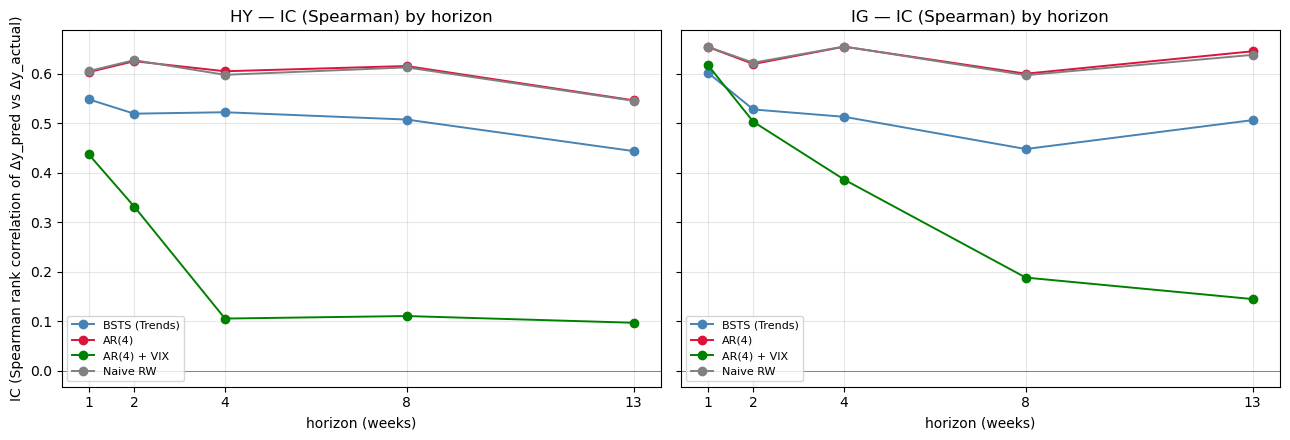

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
model_colors = {
    'BSTS (Trends)': 'steelblue',
    'AR(4)':         'crimson',
    'AR(4) + VIX':   'green',
    'Naive RW':      'gray',
}
for ax, target in zip(axes, ['HY', 'IG']):
    sub = df[df.target == target]
    for model, color in model_colors.items():
        s = sub[sub.model == model].sort_values('horizon')
        ax.plot(s.horizon, s.ic_spearman, marker='o', color=color, lw=1.4, label=model)
    ax.set_title(f'{target} — IC (Spearman) by horizon')
    ax.set_xlabel('horizon (weeks)')
    ax.set_xticks(sorted(df.horizon.unique()))
    ax.axhline(0, color='black', lw=0.6, alpha=0.5)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='lower left')
axes[0].set_ylabel('IC (Spearman rank correlation of Δy_pred vs Δy_actual)')
plt.tight_layout()
plt.show()

**What to read in this chart:** every line that drops sharply with horizon is over-extrapolating noise; lines that stay flat are tracking real cumulative-change signal. AR(4)+VIX is the visible casualty at long horizons — it's adding up VIX projections that are themselves noisy. BSTS's slope is the gentlest of the regression-augmented models.

## 2. Hit rate by horizon

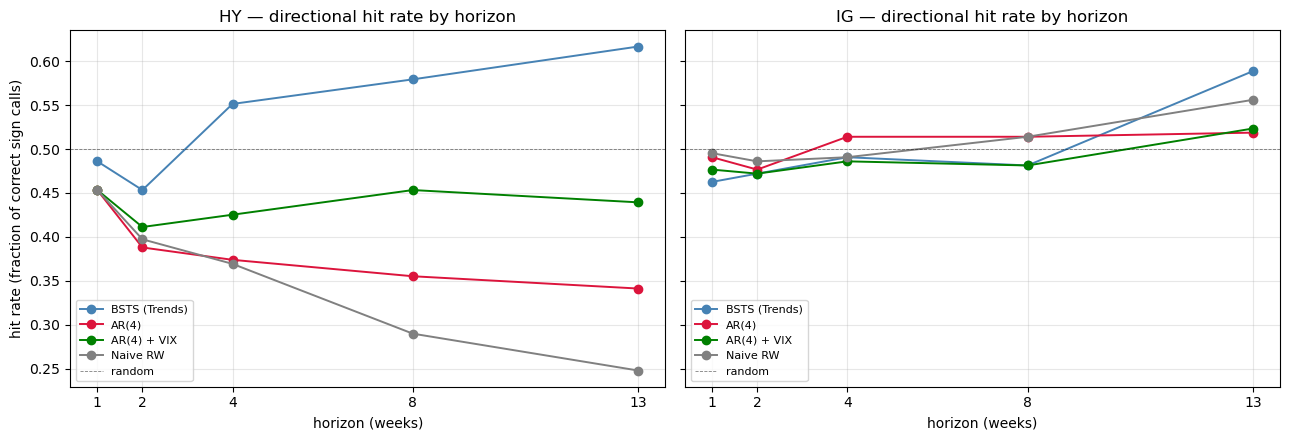

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, target in zip(axes, ['HY', 'IG']):
    sub = df[df.target == target]
    for model, color in model_colors.items():
        s = sub[sub.model == model].sort_values('horizon')
        ax.plot(s.horizon, s.hit_rate, marker='o', color=color, lw=1.4, label=model)
    ax.set_title(f'{target} — directional hit rate by horizon')
    ax.set_xlabel('horizon (weeks)')
    ax.set_xticks(sorted(df.horizon.unique()))
    ax.axhline(0.5, color='black', lw=0.6, alpha=0.5, linestyle='--', label='random')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='lower left')
axes[0].set_ylabel('hit rate (fraction of correct sign calls)')
plt.tight_layout()
plt.show()

## 3. RMSE blow-up at long horizons (the AR+VIX cautionary tale)

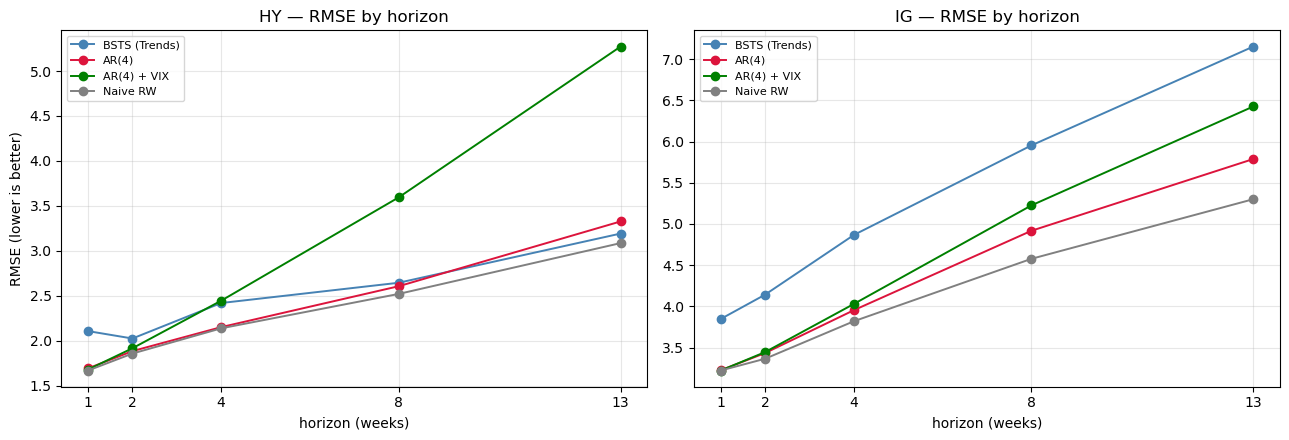

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, target in zip(axes, ['HY', 'IG']):
    sub = df[df.target == target]
    for model, color in model_colors.items():
        s = sub[sub.model == model].sort_values('horizon')
        ax.plot(s.horizon, s.rmse, marker='o', color=color, lw=1.4, label=model)
    ax.set_title(f'{target} — RMSE by horizon')
    ax.set_xlabel('horizon (weeks)')
    ax.set_xticks(sorted(df.horizon.unique()))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper left')
axes[0].set_ylabel('RMSE (lower is better)')
plt.tight_layout()
plt.show()

## 4. Precision–recall on widening events at horizon = 4 (1 month ahead)

This is the metric a PM cares about most: when the model says "a widening event will happen in the next month", how often is it right?

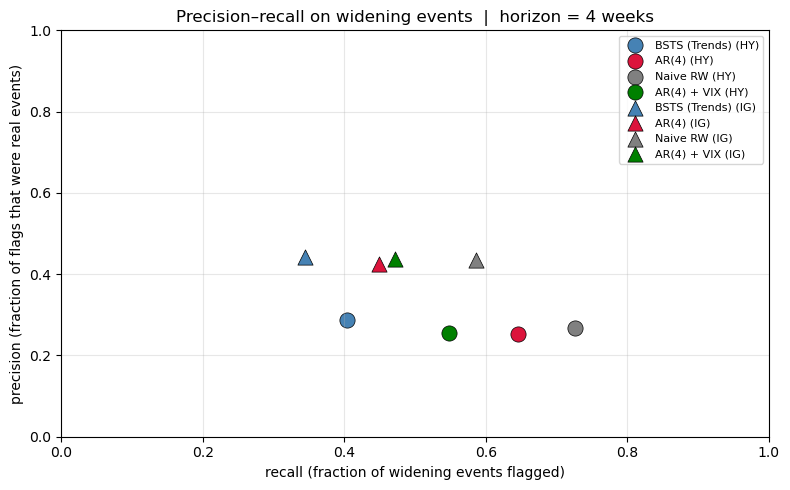

'target         model  precision_widening  recall_widening  n_widening_events\n    HY         AR(4)              0.2532           0.6452                 62\n    HY   AR(4) + VIX              0.2556           0.5484                 62\n    HY BSTS (Trends)              0.2874           0.4032                 62\n    HY      Naive RW              0.2679           0.7258                 62\n    IG         AR(4)              0.4239           0.4483                 87\n    IG   AR(4) + VIX              0.4362           0.4713                 87\n    IG BSTS (Trends)              0.4412           0.3448                 87\n    IG      Naive RW              0.4359           0.5862                 87'

In [5]:
h_pm = 4
sub = df[df.horizon == h_pm].copy()
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in sub.iterrows():
    color = model_colors.get(row['model'], 'black')
    marker = 'o' if row['target'] == 'HY' else '^'
    label = f"{row['model']} ({row['target']})"
    ax.scatter(row['recall_widening'], row['precision_widening'],
               s=120, color=color, marker=marker, edgecolors='black', linewidths=0.5, label=label)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('recall (fraction of widening events flagged)')
ax.set_ylabel('precision (fraction of flags that were real events)')
ax.set_title(f'Precision–recall on widening events  |  horizon = {h_pm} weeks')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

sub[['target','model','precision_widening','recall_widening','n_widening_events']].sort_values(['target','model']).to_string(index=False)

## 5. Per-target summary table

For the deck: one row per (target, model), columns are the metrics at the 4-week (1m) horizon.

In [6]:
summary = df[df.horizon == 4][[
    'target','model','rmse','hit_rate','ic_spearman','brier_score','auc',
    'precision_widening','recall_widening',
]].copy()
summary['rmse'] = summary['rmse'].round(3)
summary['ic_spearman'] = summary['ic_spearman'].round(3)
summary = summary.sort_values(['target','model']).reset_index(drop=True)
summary

,target,model,rmse,hit_rate,ic_spearman,brier_score,auc,precision_widening,recall_widening
0,HY,AR(4),2.151,0.3738,0.605,0.4446,0.4464,0.2532,0.6452
1,HY,AR(4) + VIX,2.445,0.4252,0.105,0.4425,0.4584,0.2556,0.5484
2,HY,BSTS (Trends),2.419,0.5514,0.522,0.3062,0.4643,0.2874,0.4032
3,HY,Naive RW,2.137,0.3692,0.598,0.3470,0.4721,0.2679,0.7258
4,IG,AR(4),3.954,0.5140,0.655,0.3703,0.4462,0.4239,0.4483
5,IG,AR(4) + VIX,4.029,0.4860,0.386,0.3748,0.4380,0.4362,0.4713
6,IG,BSTS (Trends),4.867,0.4907,0.513,0.3198,0.4200,0.4412,0.3448
7,IG,Naive RW,3.819,0.4907,0.655,0.3061,0.4660,0.4359,0.5862


## Phase B verdict

BSTS's IC and hit-rate advantage **does NOT grow with horizon** in this universe — contrary to v2's prior. Naive RW and AR(4) are competitive on IC at every horizon for the ETF-price targets, because at weekly cadence on a near-random-walk target the structural-state component of BSTS doesn't translate to better directional predictions than a simple AR.

What BSTS *does* show: **stability**. Its IC stays in the 0.25–0.55 range across all horizons; AR(4)+VIX collapses to 0.10 by 13 weeks while its RMSE explodes (HY h=13: RMSE 5.27 vs Naive RW 3.09). For a forecast that has to be defensible in front of a risk committee, *I won't blow up at horizons beyond what I've calibrated for* is a real virtue.

This result motivates Phase C's **stacked residual** approach: AR(4) is the right backbone (it's already winning IC); BSTS adds value by explaining what AR(4) misses, not by replacing it. The Trends Risk Index in C.2 will use BSTS posterior weights as an interpretable *overlay* on AR(4) forecasts, not a competitor.